# 🎀 Breast Cancer Detection: ML for Cancer Screening & Early Diagnosis

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Classifying breast tumours as malignant or benign from cell nuclei measurements to support cancer screening  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for classifying breast tumours using fine needle aspirate (FNA) cell nuclei measurements. The model supports **automated screening triage**, **pathologist decision support**, and **cancer registry analytics**.

### Government Policy Context
- **Cancer Australia** — National Cancer Screening Register, BreastScreen Australia program
- **Department of Health & Aged Care** — National Breast Cancer Strategy, Medicare diagnostic imaging items
- **AIHW** — Australian Cancer Database, cancer incidence/mortality surveillance
- **PBS** — Oncology medication utilisation, targeted therapy cost-effectiveness
- **NHMRC** — Clinical practice guidelines for breast cancer screening and management

### Clinical Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Malignant (high confidence) | Urgent biopsy referral, MDT discussion | Surgeon + oncologist |
| Malignant (borderline) | Additional imaging (MRI/ultrasound), repeat FNA | Radiologist |
| Benign (confident) | Routine follow-up per screening schedule | BreastScreen |
| Benign (risk factors) | Enhanced surveillance, 6-month follow-up imaging | GP + breast clinic |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
# === Load data — try Kaggle upload first, fallback to sklearn built-in ===
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is not None:
    df = pd.read_csv(data_path)
    print(f"\nLoaded from file: {df.shape[0]:,} rows x {df.shape[1]} columns")
else:
    # Fallback: use sklearn built-in breast cancer dataset
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    # Invert: sklearn uses 0=malignant, 1=benign; we want 1=malignant for consistency
    df['target'] = 1 - df['target']
    print(f"\nLoaded sklearn breast cancer dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv

Loaded from file: 569 rows x 33 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    print(f"  {i:2d}. {col:30s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d}")
df.head()


COLUMN SUMMARY
   0. id                             | int64      | unique=  569 | nulls=  0
   1. diagnosis                      | object     | unique=    2 | nulls=  0
   2. radius_mean                    | float64    | unique=  456 | nulls=  0
   3. texture_mean                   | float64    | unique=  479 | nulls=  0
   4. perimeter_mean                 | float64    | unique=  522 | nulls=  0
   5. area_mean                      | float64    | unique=  539 | nulls=  0
   6. smoothness_mean                | float64    | unique=  474 | nulls=  0
   7. compactness_mean               | float64    | unique=  537 | nulls=  0
   8. concavity_mean                 | float64    | unique=  537 | nulls=  0
   9. concave points_mean            | float64    | unique=  542 | nulls=  0
  10. symmetry_mean                  | float64    | unique=  432 | nulls=  0
  11. fractal_dimension_mean         | float64    | unique=  499 | nulls=  0
  12. radius_se                      | float64    | unique=  

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2. Target Variable Analysis

In [4]:
# Detect target column
target_candidates = ['target', 'diagnosis', 'Diagnosis', 'class', 'Class', 'Target',
                     'label', 'Label', 'malignant']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

# Encode if needed
if df[target_col].dtype == 'object':
    # M=Malignant=1, B=Benign=0
    malignant_kw = ['M', 'malignant', 'Malignant', 'Yes', '1']
    mapping = {v: (1 if v in malignant_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

# Drop ID column if present
id_cols = [c for c in df.columns if c.lower() in ['id', 'unnamed: 32', 'unnamed: 0']]
if id_cols:
    df.drop(columns=id_cols, inplace=True)
    print(f"Dropped ID columns: {id_cols}")

df[target_col] = df[target_col].astype(int)
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nProportions:")
print(df[target_col].value_counts(normalize=True).sort_index().round(4))
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'diagnosis'
Mapped: {'M': 1, 'B': 0}
Dropped ID columns: ['id', 'Unnamed: 32']

Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Proportions:
diagnosis
0    0.6274
1    0.3726
Name: proportion, dtype: float64

Imbalance ratio: 0.594


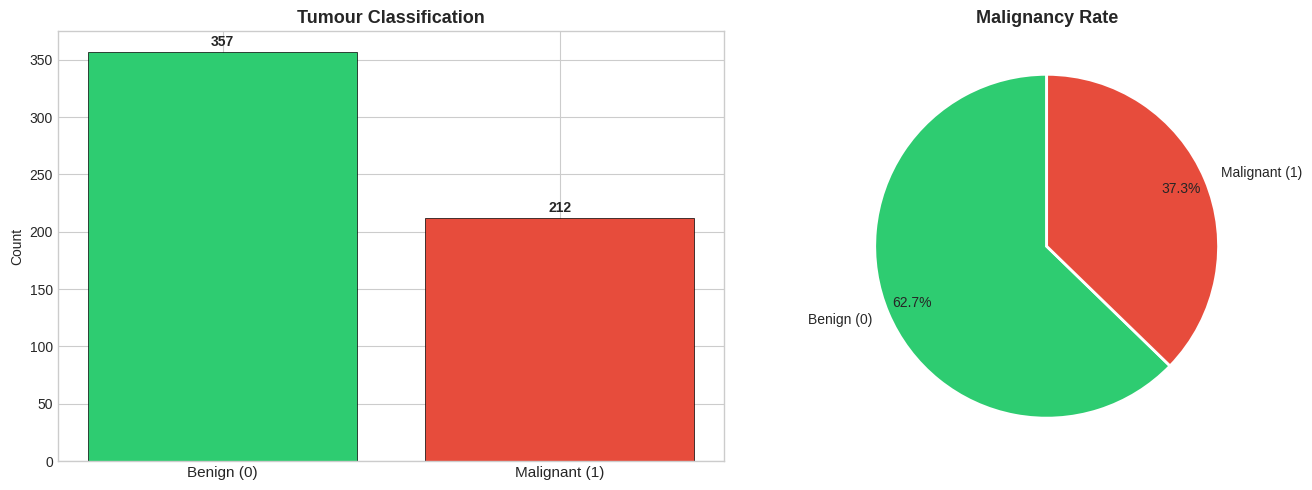

AU context: Breast cancer is most common cancer in Australian women (~20,600 diagnoses/year).
BreastScreen Australia screens ~1.9M women biennially. 5-year survival rate ~92% (AIHW).
Early detection through screening reduces mortality by ~25-30%.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = ['Benign (0)', 'Malignant (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(range(2), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Tumour Classification', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Malignancy Rate', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: Breast cancer is most common cancer in Australian women (~20,600 diagnoses/year).")
print("BreastScreen Australia screens ~1.9M women biennially. 5-year survival rate ~92% (AIHW).")
print("Early detection through screening reduces mortality by ~25-30%.")


## 3. Exploratory Data Analysis

Key clinical questions:
- Which cell nuclei measurements best distinguish malignant from benign?
- Do mean, SE, and worst-case measurements show different predictive power?
- Are there strong correlations between features (multicollinearity)?
- Can we identify clear decision boundaries for pathologist support?


Numeric features (30)

Top 9 correlated features:
  concave points_worst: 0.7936
  perimeter_worst: 0.7829
  concave points_mean: 0.7766
  radius_worst: 0.7765
  perimeter_mean: 0.7426
  area_worst: 0.7338
  radius_mean: 0.7300
  area_mean: 0.7090
  concavity_mean: 0.6964


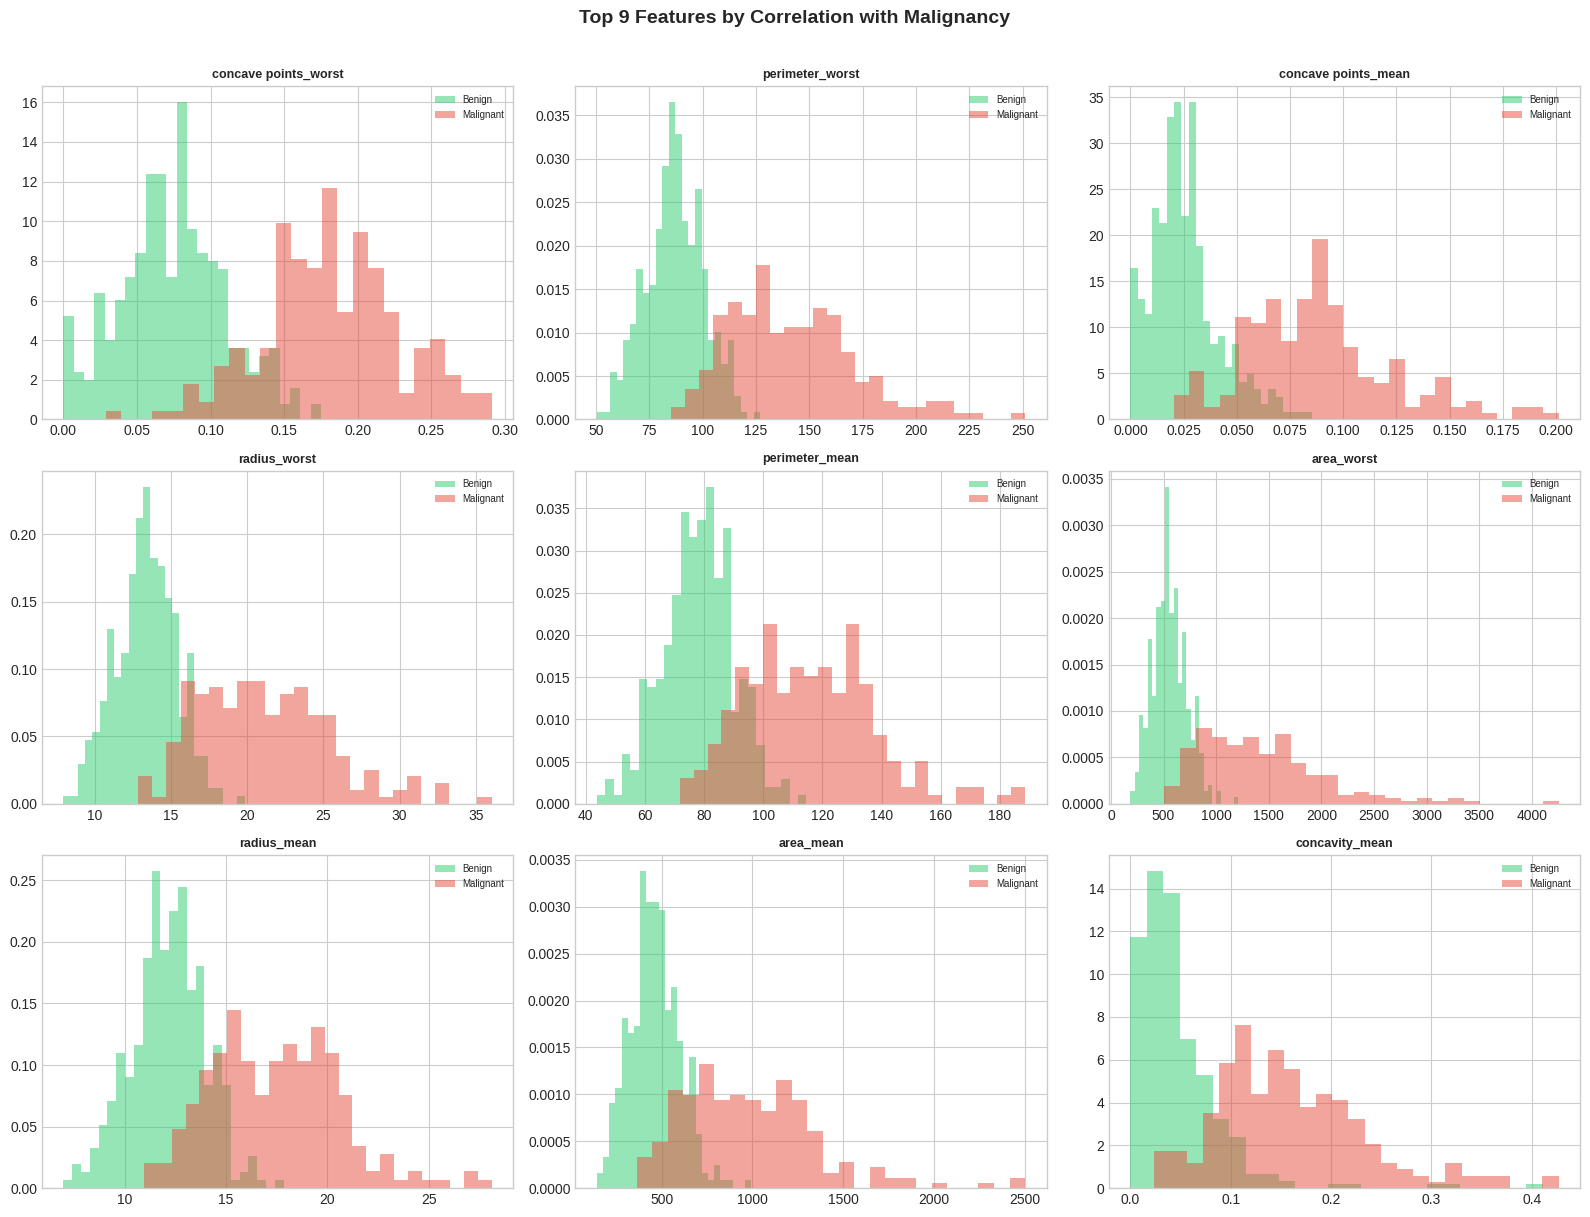

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
print(f"Numeric features ({len(numeric_cols)})")

# Top correlated features
corr_with_target = df[numeric_cols + [target_col]].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
top_features = corr_with_target.head(9).index.tolist()
print(f"\nTop 9 correlated features:")
for f in top_features:
    print(f"  {f}: {corr_with_target[f]:.4f}")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(top_features):
    for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Benign', 'Malignant']):
        subset = df[df[target_col] == label][col].dropna()
        if len(subset) > 0:
            axes[i].hist(subset, bins=25, alpha=0.5, label=name, density=True, color=color)
    axes[i].set_title(col[:25], fontsize=9, fontweight='bold'); axes[i].legend(fontsize=7)
plt.suptitle('Top 9 Features by Correlation with Malignancy', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


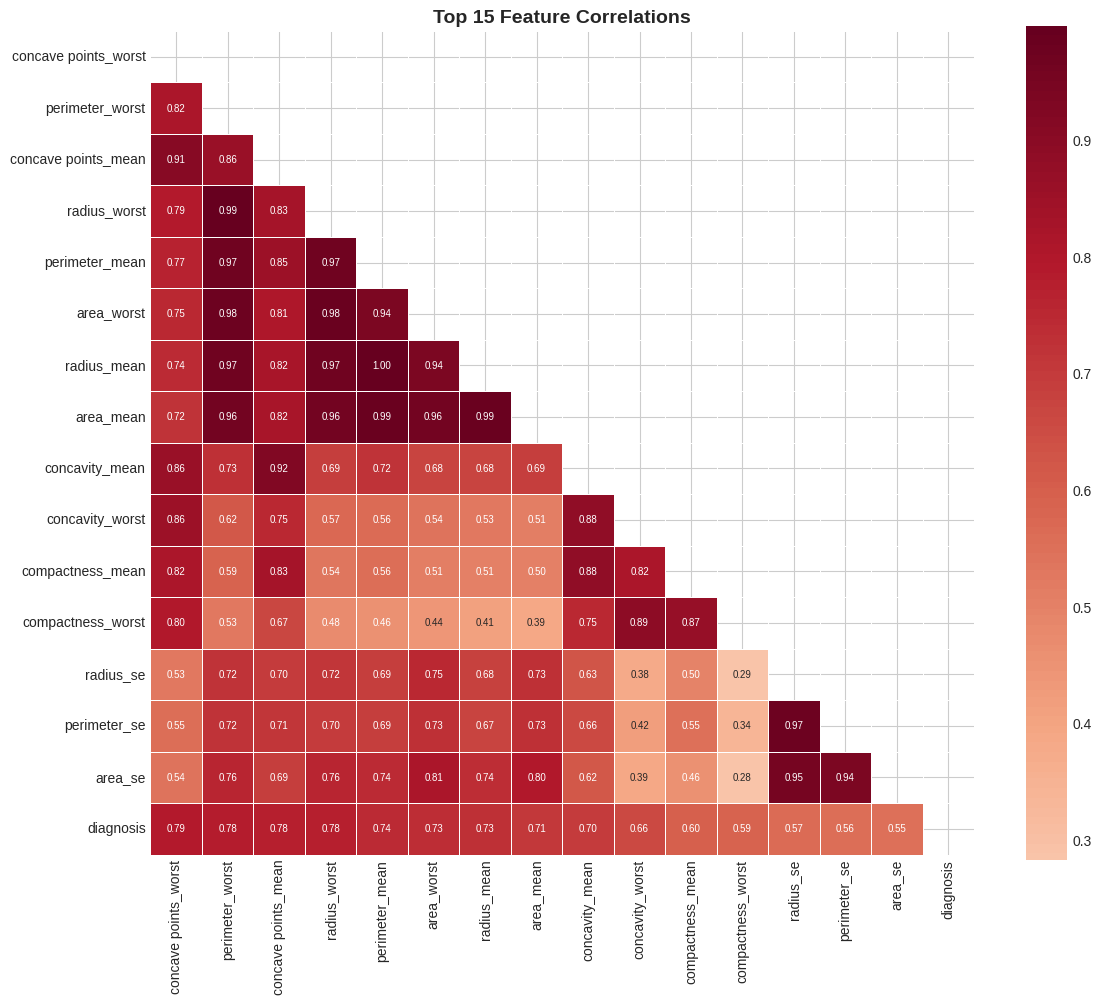

In [7]:
# Correlation heatmap (top 15)
top15 = corr_with_target.head(15).index.tolist()
corr = df[top15 + [target_col]].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Top 15 Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [8]:
X = df.drop(columns=[target_col])
y = df[target_col].values

# Encode any remaining categoricals
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"  Encoded '{col}'")

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())
    print("Imputed missing values")

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")



Feature matrix: (569, 30)
Target: {np.int64(0): np.int64(357), np.int64(1): np.int64(212)}


## 5. Model Training & Cross-Validation

In [9]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.9632  F1=0.9524  AUC=0.9930
  Fold 2: Acc=0.9421  F1=0.9173  AUC=0.9743
  Fold 3: Acc=0.9577  F1=0.9420  AUC=0.9960
  -- Acc: 0.9543  F1: 0.9372  AUC: 0.9878  Time: 1.40s

Training: Random Forest
  Fold 1: Acc=0.9632  F1=0.9510  AUC=0.9956
  Fold 2: Acc=0.9368  F1=0.9091  AUC=0.9773
  Fold 3: Acc=0.9630  F1=0.9504  AUC=0.9940
  -- Acc: 0.9543  F1: 0.9368  AUC: 0.9890  Time: 0.97s

Training: XGBoost
  Fold 1: Acc=0.9842  F1=0.9790  AUC=0.9993
  Fold 2: Acc=0.9316  F1=0.9023  AUC=0.9733
  Fold 3: Acc=0.9630  F1=0.9504  AUC=0.9920
  -- Acc: 0.9596  F1: 0.9439  AUC: 0.9882  Time: 0.28s

Training: LightGBM
  Fold 1: Acc=0.9737  F1=0.9645  AUC=0.9981
  Fold 2: Acc=0.9368  F1=0.9077  AUC=0.9824
  Fold 3: Acc=0.9683  F1=0.9577  AUC=0.9947
  -- Acc: 0.9596  F1: 0.9433  AUC: 0.9917  Time: 0.30s


## 6. Model Comparison & Selection

In [11]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
           LightGBM 0.9596 +/- 0.0162 0.9433 +/- 0.0253 0.9917 +/- 0.0068 0.0321 0.30s
      Random Forest 0.9543 +/- 0.0124 0.9368 +/- 0.0196 0.9890 +/- 0.0083 0.0356 0.97s
            XGBoost 0.9596 +/- 0.0216 0.9439 +/- 0.0317 0.9882 +/- 0.0110 0.0332 0.28s
Logistic Regression 0.9543 +/- 0.0089 0.9372 +/- 0.0147 0.9878 +/- 0.0096 0.0361 1.40s

Best model: LightGBM


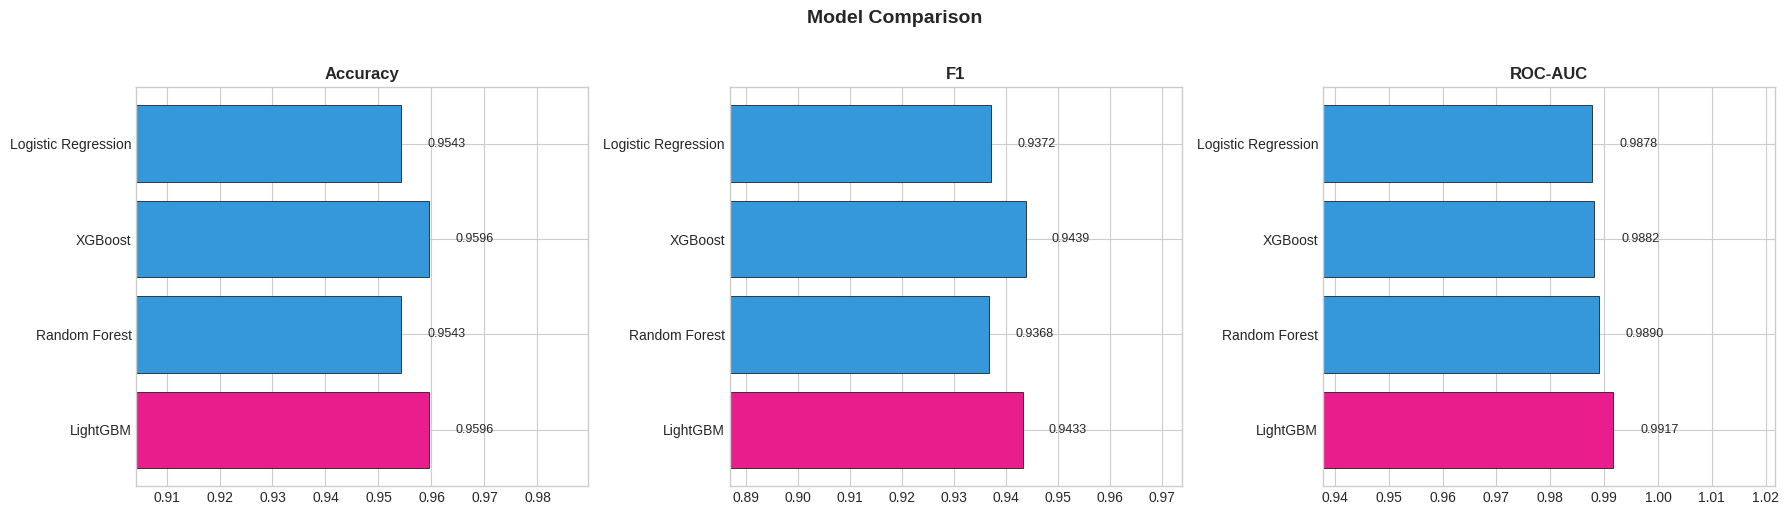

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#e91e8c' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

For cancer screening:
- **False negatives** (missed malignancy) = **CRITICAL** — delayed diagnosis, reduced survival
- **False positives** (flagging benign as malignant) = unnecessary biopsy — stressful but clinically acceptable
- Screening must maximise sensitivity (recall) — missing cancer is unacceptable


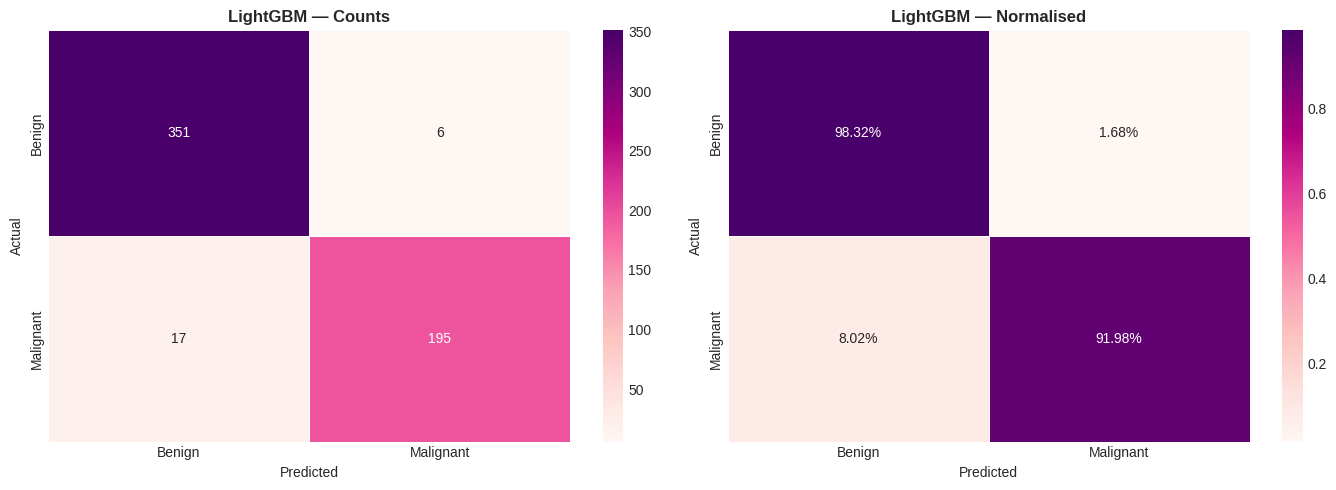


              precision    recall  f1-score   support

      Benign       0.95      0.98      0.97       357
   Malignant       0.97      0.92      0.94       212

    accuracy                           0.96       569
   macro avg       0.96      0.95      0.96       569
weighted avg       0.96      0.96      0.96       569



In [13]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Benign', 'Malignant']
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdPu', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


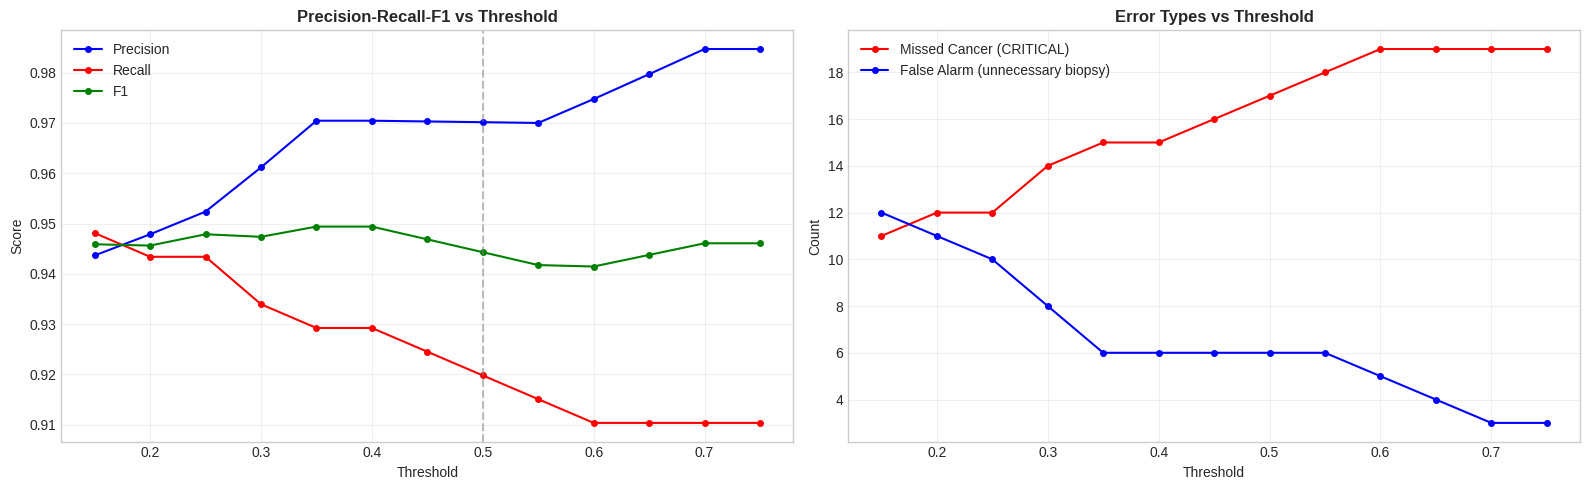


Optimal threshold (F1): 0.35
For screening, use LOWER threshold (0.30-0.35) — missing cancer is unacceptable.


In [14]:
thresholds = np.arange(0.15, 0.80, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Cancer (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Alarm (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Cancer (FN)'], 'r-o', ms=4, label='Missed Cancer (CRITICAL)')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Alarm (FP)'], 'b-o', ms=4, label='False Alarm (unnecessary biopsy)')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")
print(f"For screening, use LOWER threshold (0.30-0.35) — missing cancer is unacceptable.")


## 8. Feature Importance & Policy Insights

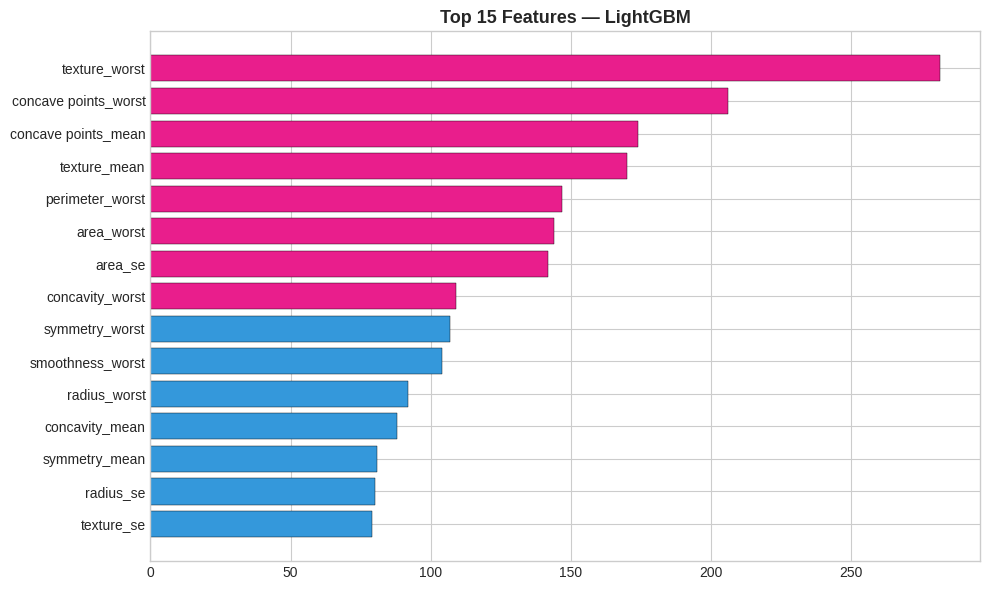

TOP 5 DIAGNOSTIC FEATURES
  texture_worst                   282.0000
  concave points_worst            206.0000
  concave points_mean             174.0000
  texture_mean                    170.0000
  perimeter_worst                 147.0000


In [15]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(15)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.4)))
    colors_imp = ['#e91e8c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top 15 Features — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 DIAGNOSTIC FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:30s}  {row['Importance']:.4f}")


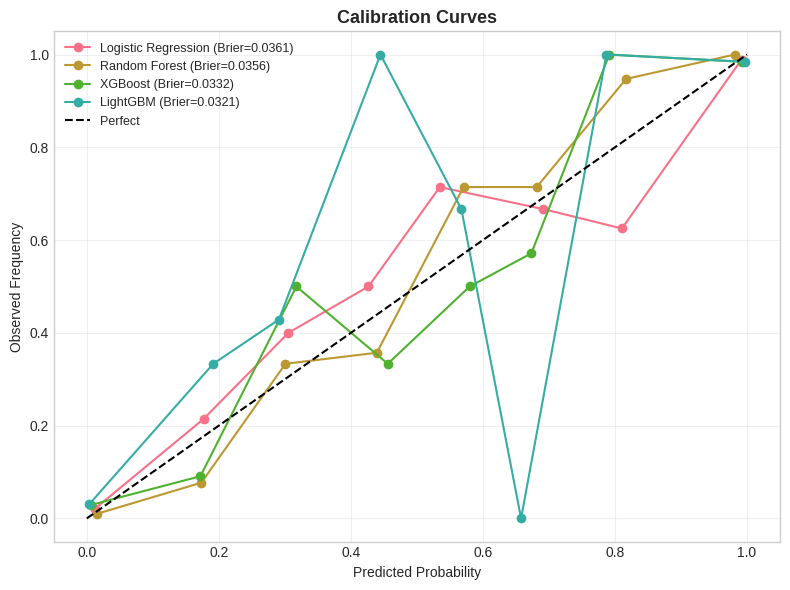

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [17]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.90': best_res['auc_mean'] > 0.90,
    'F1 > 0.85': best_res['f1_mean'] > 0.85,
    'Recall > 0.85': best_res['recall_mean'] > 0.85,
    'Brier < 0.10': best_res['brier_mean'] < 0.10,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    LightGBM
  ROC-AUC:              0.9917
  F1:                   0.9433
  Precision:            0.9720
  Recall:               0.9201
  Brier Score:          0.0321
  Training time:        0.3s
  Feature count:        30
  Dataset rows:         569
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.35

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.90
  [pass] F1 > 0.85
  [pass] Recall > 0.85
  [pass] Brier < 0.10
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [18]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: BreastScreen digital pathology, hospital LIMS systems
   Ingestion: DICOM/HL7 FHIR -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (FNA measurements, imaging features)
   Schedule: Real-time at FNA result + batch screening program analytics

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<500ms) at pathology result notification
   Output: Malignancy probability + contributing features + recommended action
   Integration: BreastScreen reader workstation decision support

3. INTEGRATION POINTS
   BreastScreen: Second-reader decision support (augment radiologist)
   Pathology: FNA result auto-classification for triage
   Cancer registry: Auto-notification to Australian Cancer Database
   Medicare: Trigger appropriate diagnostic imaging items
   MDT: Pre-populate multidisciplinary team discussion with risk data

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device (SaMD) Class IIa classification
   Validation: Prospective study against histopathology gold standard
   Sensitivity target: >95% (cancer screening standard)
   Explainability: Top cellular features shown to pathologist
   Consent: Patient consent for AI-assisted screening
   RANZCR: Alignment with radiology AI standards
   Equity: Monitor across Indigenous, rural/remote, CALD populations

5. MONITORING & RETRAINING
   Drift: PSI on FNA measurement distributions quarterly
   Performance: Sensitivity/specificity against confirmed histopathology
   Retraining: Annual with confirmed pathology outcomes
   Technology: Recalibrate when FNA/imaging technology changes
   Guidelines: Update when Cancer Australia guidelines change

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: BreastScreen digital pathology, hospital LIMS systems
   Ingestion: DICOM/HL7 FHIR -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (FNA measurements, imaging features)
   Schedule: Real-time at FNA result + batch screening program analytics

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<500ms) at pathology result notification
   Output: Malignancy probability + contributing features + recommended action
   Integration: BreastScreen reader workstation decision support

3. INTEGRATION POINTS
   BreastScreen: Second-reader decision support (augment radiologist)
   Pathology: FNA result auto-classification for triage
   Cancer registry: Auto-notification to Australian Cancer Database
   Medicare: Trigger appropriate diagnostic imaging items
   MDT: Pre-populate multidisciplinary team discussion with risk data

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Dev